Time Series Forecasting: Johnson & Johnson and Amazon

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


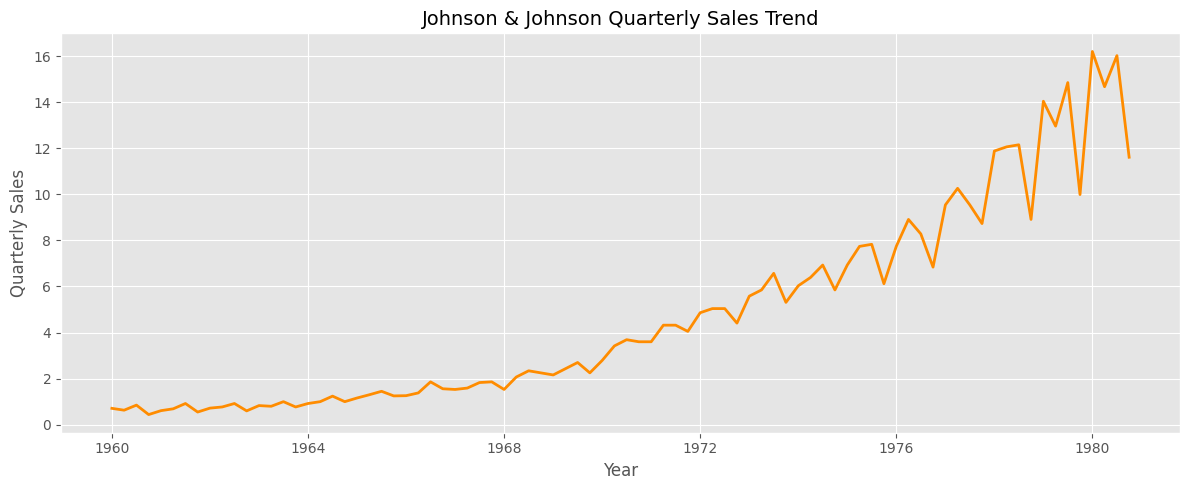

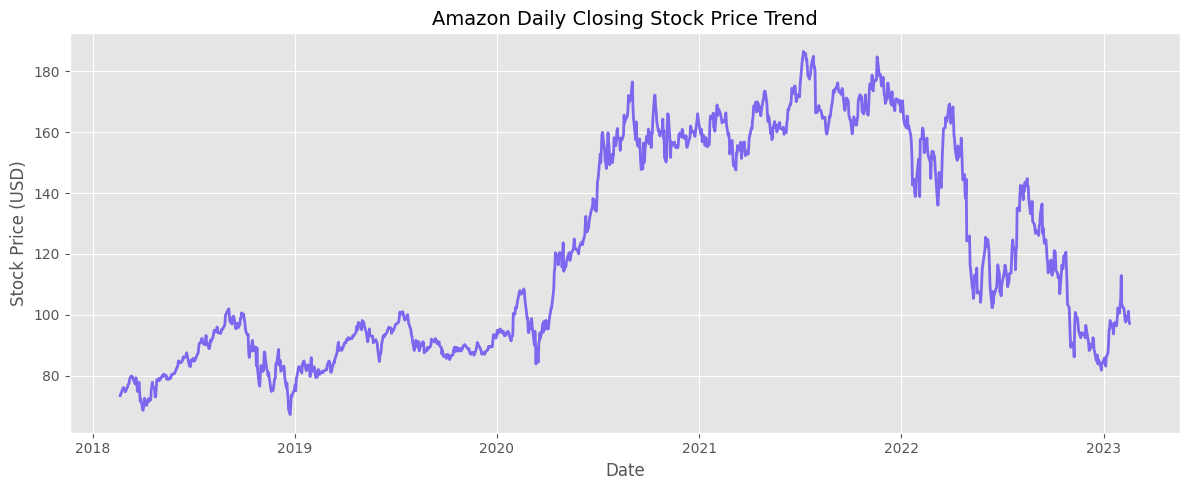

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

# Set plot style for consistency
plt.style.use('ggplot')

# Load Johnson & Johnson sales data
jj_data = pd.read_csv("/content/drive/MyDrive/jj.csv")

# Load Amazon stock price data
amzn_data = pd.read_csv("/content/drive/MyDrive/AMZN.csv")

# Rename sales column for clarity
jj_data.columns = ['Date', 'Quarterly_Sales']
# Set 'Date' as the datetime index
jj_data['Date'] = pd.to_datetime(jj_data['Date'])
jj_data.set_index('Date', inplace=True)

# Extract only necessary columns and convert date for Amazon data
amzn_data = amzn_data[['Date', 'Close']]
amzn_data['Date'] = pd.to_datetime(amzn_data['Date'])
amzn_data.set_index('Date', inplace=True)

# Plot Johnson & Johnson sales time series
plt.figure(figsize=(12, 5))
plt.plot(jj_data, color='darkorange', linewidth=2)
plt.title('Johnson & Johnson Quarterly Sales Trend', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Quarterly Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Amazon closing stock prices time series
plt.figure(figsize=(12, 5))
plt.plot(amzn_data, color='mediumslateblue', linewidth=2)
plt.title('Amazon Daily Closing Stock Price Trend', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()


ADF Test for: Johnson & Johnson Quarterly Sales
ADF Statistic: 2.7420
p-value: 1.0000
=> Series is Non-Stationary
--------------------------------------------------
ADF Test for: Amazon Closing Stock Price
ADF Statistic: -1.6578
p-value: 0.4530
=> Series is Non-Stationary
--------------------------------------------------
ADF Test for: J&J Sales (1st Difference)
ADF Statistic: -0.4074
p-value: 0.9089
=> Series is Non-Stationary
--------------------------------------------------
ADF Test for: Amazon Price (1st Difference)
ADF Statistic: -36.2508
p-value: 0.0000
=> Series is Stationary
--------------------------------------------------


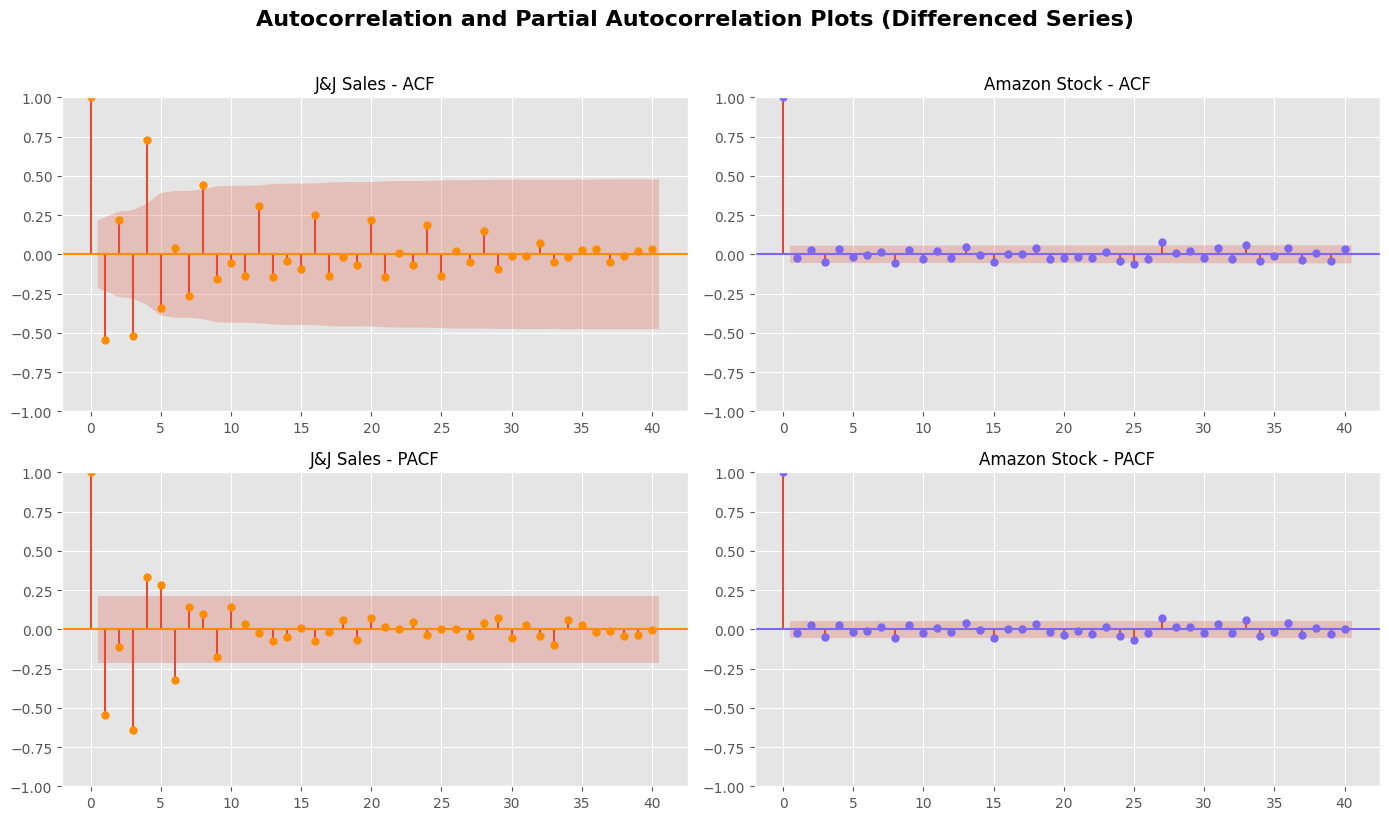

In [ ]:
# Function to perform Augmented Dickey-Fuller test and display results
def adf_test(time_series, title=''):
    print(f'ADF Test for: {title}')
    result = adfuller(time_series.dropna(), autolag='AIC')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('=> Series is Stationary' if result[1] < 0.05 else '=> Series is Non-Stationary')
    print('-' * 50)

# Run ADF test on original time series
adf_test(jj_data['Quarterly_Sales'], 'Johnson & Johnson Quarterly Sales')
adf_test(amzn_data['Close'], 'Amazon Closing Stock Price')

# Apply first-order differencing to induce stationarity
jj_diff = jj_data['Quarterly_Sales'].diff().dropna()
amzn_diff = amzn_data['Close'].diff().dropna()

# Re-evaluate stationarity after differencing
adf_test(jj_diff, 'J&J Sales (1st Difference)')
adf_test(amzn_diff, 'Amazon Price (1st Difference)')

# Plotting ACF and PACF to identify autocorrelation patterns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set up subplots for visualizing both series
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Autocorrelation and Partial Autocorrelation Plots (Differenced Series)",
             fontsize=16, fontweight='bold', y=1.02)

# ACF and PACF for Johnson & Johnson sales
plot_acf(jj_diff, ax=ax[0, 0], lags=40, color='darkorange')
ax[0, 0].set_title("J&J Sales - ACF", fontsize=12)
ax[0, 0].grid(True)

plot_pacf(jj_diff, ax=ax[1, 0], lags=40, method='ywm', color='darkorange')
ax[1, 0].set_title("J&J Sales - PACF", fontsize=12)
ax[1, 0].grid(True)

# ACF and PACF for Amazon stock price
plot_acf(amzn_diff, ax=ax[0, 1], lags=40, color='mediumslateblue')
ax[0, 1].set_title("Amazon Stock - ACF", fontsize=12)
ax[0, 1].grid(True)

plot_pacf(amzn_diff, ax=ax[1, 1], lags=40, method='ywm', color='mediumslateblue')
ax[1, 1].set_title("Amazon Stock - PACF", fontsize=12)
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()


ARIMA (ARMA) Modelling and Forecast

                               SARIMAX Results                                
Dep. Variable:        Quarterly_Sales   No. Observations:                   84
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -128.371
Date:                Sat, 12 Apr 2025   AIC                            262.742
Time:                        09:19:32   BIC                            269.998
Sample:                             0   HQIC                           265.657
                                 - 84                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3277      0.090     -3.657      0.000      -0.503      -0.152
ma.L1         -0.4313      0.093     -4.662      0.000      -0.613      -0.250
sigma2         1.2819      0.164      7.814      0.0

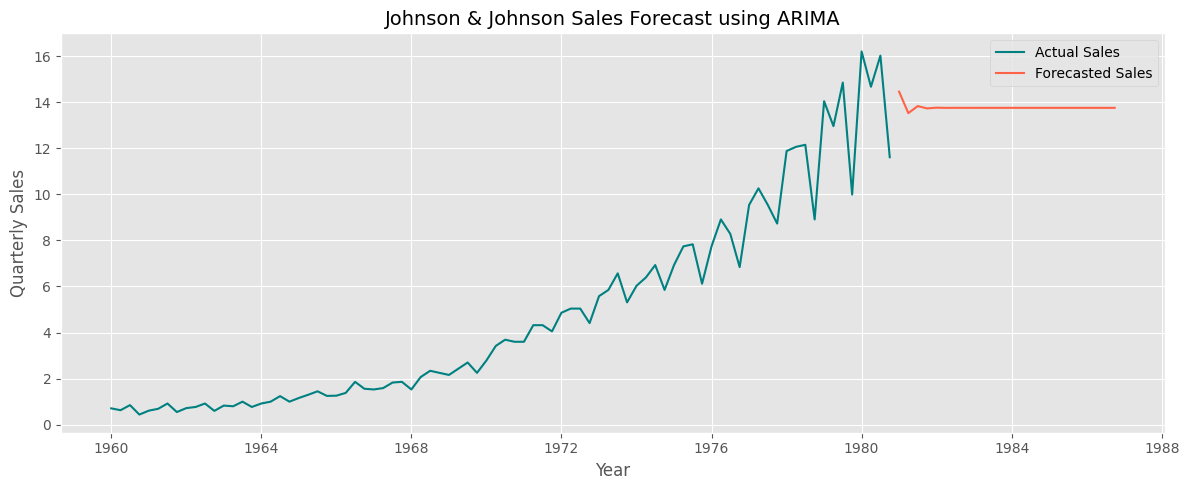

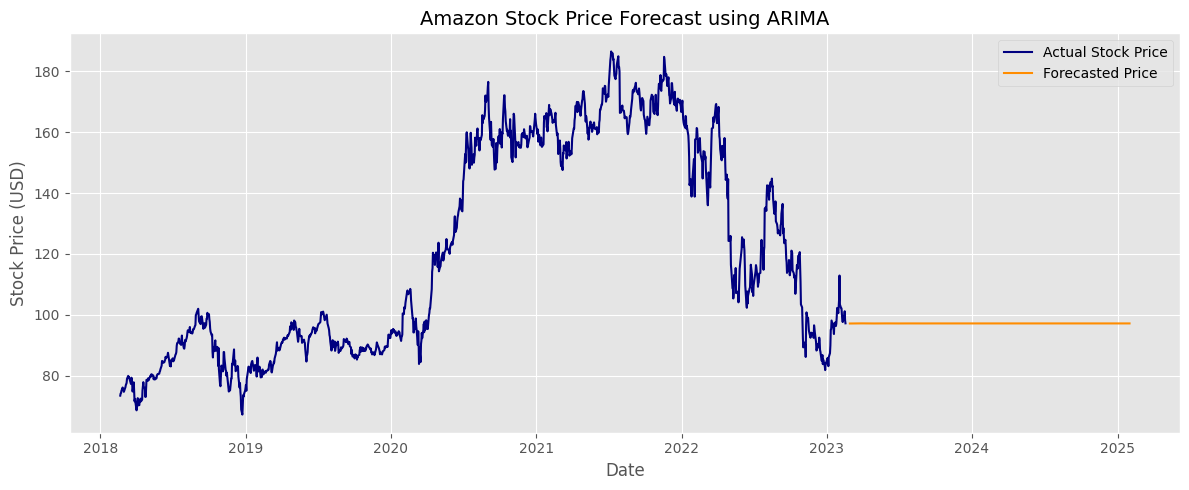

In [ ]:
# Build and fit ARIMA model for Johnson & Johnson sales
jj_arima_model = ARIMA(jj_data['Quarterly_Sales'], order=(1, 1, 1))  # Tune (p,d,q) using AIC/BIC as needed
jj_arima_fit = jj_arima_model.fit()
print(jj_arima_fit.summary())

# Build and fit ARIMA model for Amazon stock prices
amzn_arima_model = ARIMA(amzn_data['Close'], order=(1, 1, 1))  # Tune (p,d,q) using AIC/BIC as needed
amzn_arima_fit = amzn_arima_model.fit()
print(amzn_arima_fit.summary())

# Forecast the next 24 time steps (quarters for J&J, months for Amazon)
jj_forecast = jj_arima_fit.forecast(steps=24)
amzn_forecast = amzn_arima_fit.forecast(steps=24)

# Plot J&J forecast
plt.figure(figsize=(12, 5))
plt.plot(jj_data['Quarterly_Sales'], label='Actual Sales', color='teal')
plt.plot(pd.date_range(start=jj_data.index[-1] + pd.offsets.QuarterEnd(), periods=24, freq='Q'),
         jj_forecast, label='Forecasted Sales', color='tomato')
plt.title('Johnson & Johnson Sales Forecast using ARIMA', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Quarterly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Amazon forecast
plt.figure(figsize=(12, 5))
plt.plot(amzn_data['Close'], label='Actual Stock Price', color='navy')
plt.plot(pd.date_range(start=amzn_data.index[-1] + pd.offsets.MonthEnd(), periods=24, freq='M'),
         amzn_forecast, label='Forecasted Price', color='darkorange')
plt.title('Amazon Stock Price Forecast using ARIMA', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


 Neural Network Forecasting (LSTM / GRU)

In [ ]:
# -----------------------------
# Helper function to generate lagged input-output pairs for RNN training
# -----------------------------
def prepare_lagged_sequences(series, n_lags=12):
    """
    Transform a time series into lagged sequences suitable for RNN models.

    Parameters:
        series (array-like): Normalized 1D time series data.
        n_lags (int): Number of past time steps to use as input.

    Returns:
        tuple: Arrays for input features (X) and target labels (y).
    """
    X, y = [], []
    for i in range(n_lags, len(series)):
        X.append(series[i - n_lags:i])
        y.append(series[i])
    return np.array(X), np.array(y)

# -----------------------------
# Apply Min-Max normalization to the time series
# -----------------------------
scaler_jj = MinMaxScaler()
jj_scaled = scaler_jj.fit_transform(jj_data['Quarterly_Sales'].values.reshape(-1, 1))

scaler_amzn = MinMaxScaler()
amzn_scaled = scaler_amzn.fit_transform(amzn_data['Close'].values.reshape(-1, 1))

# -----------------------------
# Create lagged sequences for RNN input
# -----------------------------
X_jj, y_jj = prepare_lagged_sequences(jj_scaled, n_lags=12)
X_amzn, y_amzn = prepare_lagged_sequences(amzn_scaled, n_lags=12)

# -----------------------------
# Reshape input arrays to 3D [samples, timesteps, features] for RNN
# -----------------------------
X_jj = X_jj.reshape((X_jj.shape[0], X_jj.shape[1], 1))
X_amzn = X_amzn.reshape((X_amzn.shape[0], X_amzn.shape[1], 1))

# -----------------------------
# Display data shapes for verification
# -----------------------------
print(f'J&J RNN input shape: {X_jj.shape}, Target shape: {y_jj.shape}')
print(f'Amazon RNN input shape: {X_amzn.shape}, Target shape: {y_amzn.shape}')


J&J RNN input shape: (72, 12, 1), Target shape: (72, 1)
Amazon RNN input shape: (1247, 12, 1), Target shape: (1247, 1)


In [ ]:
# -----------------------------
# Build and compile an RNN model (LSTM or GRU)
# -----------------------------
def build_model(input_shape, model_type='LSTM', units=64):
    """
    Constructs a simple RNN model using LSTM or GRU architecture.

    Parameters:
    ----------
    input_shape : tuple
        Shape of input data in the format (timesteps, features)
    model_type : str, optional
        Type of RNN layer to use: 'LSTM' or 'GRU' (default is 'LSTM')
    units : int, optional
        Number of hidden units in the RNN layer (default is 64)

    Returns:
    -------
    model : tf.keras.Model
        Compiled Keras model ready for training
    """
    model = Sequential()

    if model_type.upper() == 'LSTM':
        model.add(LSTM(units, input_shape=input_shape, return_sequences=False))
    elif model_type.upper() == 'GRU':
        model.add(GRU(units, input_shape=input_shape, return_sequences=False))
    else:
        raise ValueError("Invalid model_type. Choose either 'LSTM' or 'GRU'.")

    model.add(Dense(1))  # Final dense layer for regression output
    model.compile(optimizer='adam', loss='mse')

    return model


In [ ]:
# -----------------------------
# Train RNN model and forecast future values
# -----------------------------
def train_forecast(X, y, scaler, model_type='LSTM', forecast_steps=24):
    """
    Trains an RNN (LSTM or GRU) model on a time series and forecasts future steps.

    Parameters:
    ----------
    X : ndarray
        3D array of shape (samples, timesteps, features) representing input sequences.
    y : ndarray
        1D array of target values corresponding to each input sequence.
    scaler : MinMaxScaler
        Fitted MinMaxScaler used for inverse transforming the predictions.
    model_type : str, optional
        Type of RNN to use: 'LSTM' or 'GRU'. Default is 'LSTM'.
    forecast_steps : int, optional
        Number of future time steps to forecast. Default is 24.

    Returns:
    -------
    preds : ndarray
        Array of forecasted values, inverse transformed to the original scale.
    """
    # Build and compile the model
    model = build_model((X.shape[1], 1), model_type=model_type)
    early_stop = EarlyStopping(patience=10, restore_best_weights=True)

    # Train the model
    model.fit(X, y, epochs=100, batch_size=16, validation_split=0.2,
              callbacks=[early_stop], verbose=0)

    # Start forecasting from the last available sequence
    last_seq = X[-1]
    predictions = []

    for _ in range(forecast_steps):
        pred = model.predict(last_seq.reshape(1, -1, 1), verbose=0)[0]
        predictions.append(pred)
        # Update sequence for the next prediction
        last_seq = np.append(last_seq[1:], pred).reshape(-1, 1)

    # Convert predictions back to original scale
    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
    return predictions


In [ ]:
# -----------------------------
# Run RNN Forecasts for Johnson & Johnson and Amazon
# -----------------------------

# ---- Johnson & Johnson Sales Forecast ----
print(" Training and forecasting for Johnson & Johnson using LSTM...")
jj_lstm_forecast = train_forecast(X_jj, y_jj, scaler_jj, model_type='LSTM')

print(" Training and forecasting for Johnson & Johnson using GRU...")
jj_gru_forecast = train_forecast(X_jj, y_jj, scaler_jj, model_type='GRU')

# ---- Amazon Stock Price Forecast ----
print(" Training and forecasting for Amazon using LSTM...")
amzn_lstm_forecast = train_forecast(X_amzn, y_amzn, scaler_amzn, model_type='LSTM')

print(" Training and forecasting for Amazon using GRU...")
amzn_gru_forecast = train_forecast(X_amzn, y_amzn, scaler_amzn, model_type='GRU')


 Training and forecasting for Johnson & Johnson using LSTM...
 Training and forecasting for Johnson & Johnson using GRU...
 Training and forecasting for Amazon using LSTM...
 Training and forecasting for Amazon using GRU...


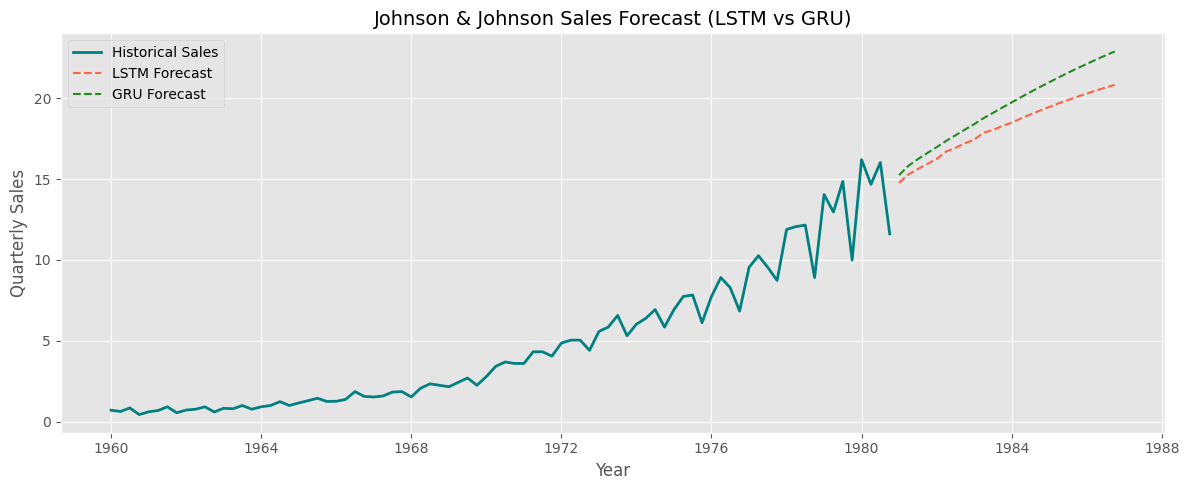

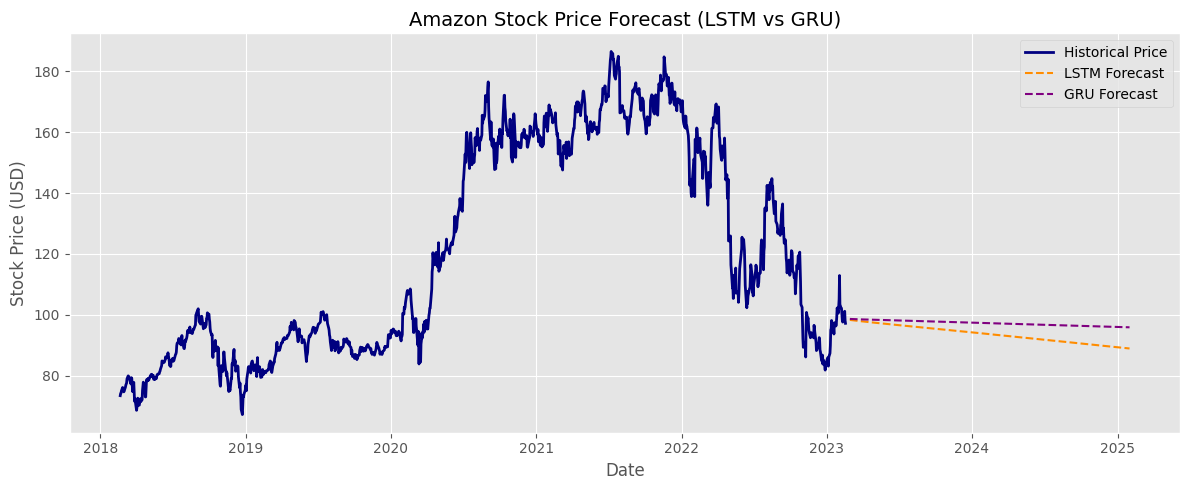

In [ ]:
# -----------------------------
# Plot RNN Forecasts: LSTM vs GRU
# -----------------------------

# ---- Johnson & Johnson Sales Forecast Plot ----
plt.figure(figsize=(12, 5))
plt.plot(jj_data['Quarterly_Sales'], label='Historical Sales', color='teal', linewidth=2)
plt.plot(pd.date_range(jj_data.index[-1] + pd.offsets.QuarterEnd(), periods=24, freq='Q'),
         jj_lstm_forecast, label='LSTM Forecast', color='tomato', linestyle='--')
plt.plot(pd.date_range(jj_data.index[-1] + pd.offsets.QuarterEnd(), periods=24, freq='Q'),
         jj_gru_forecast, label='GRU Forecast', color='forestgreen', linestyle='--')
plt.title('Johnson & Johnson Sales Forecast (LSTM vs GRU)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Quarterly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Amazon Stock Price Forecast Plot ----
plt.figure(figsize=(12, 5))
plt.plot(amzn_data['Close'], label='Historical Price', color='navy', linewidth=2)
plt.plot(pd.date_range(amzn_data.index[-1] + pd.offsets.MonthEnd(), periods=24, freq='M'),
         amzn_lstm_forecast, label='LSTM Forecast', color='darkorange', linestyle='--')
plt.plot(pd.date_range(amzn_data.index[-1] + pd.offsets.MonthEnd(), periods=24, freq='M'),
         amzn_gru_forecast, label='GRU Forecast', color='purple', linestyle='--')
plt.title('Amazon Stock Price Forecast (LSTM vs GRU)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Evaluation Metrics

In [ ]:
# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate(true, pred, model_name="Model", show_rmse=False):
    """
    Evaluate model predictions using MSE and MAE (optional RMSE).

    Parameters:
    ----------
    true : array-like
        Actual values (1D array or Series)
    pred : array-like
        Forecasted values (1D array)
    model_name : str
        Label for the model being evaluated
    show_rmse : bool
        If True, also prints RMSE
    """
    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    if show_rmse:
        rmse = np.sqrt(mse)
        print(f"{model_name:<15} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    else:
        print(f"{model_name:<15} | MSE: {mse:.4f} | MAE: {mae:.4f}")

# -----------------------------
# Get actual last 24 values for comparison
# -----------------------------
jj_true = jj_data['Quarterly_Sales'][-24:]
amzn_true = amzn_data['Close'][-24:]

# -----------------------------
# Evaluation: Johnson & Johnson
# -----------------------------
print(" Johnson & Johnson Forecast Evaluation")
evaluate(jj_true, jj_forecast, "JJ ARIMA")
evaluate(jj_true, jj_lstm_forecast, "JJ LSTM")
evaluate(jj_true, jj_gru_forecast, "JJ GRU")

# -----------------------------
# Evaluation: Amazon
# -----------------------------
print("\n Amazon Forecast Evaluation")
evaluate(amzn_true, amzn_forecast, "Amazon ARIMA")
evaluate(amzn_true, amzn_lstm_forecast, "Amazon LSTM")
evaluate(amzn_true, amzn_gru_forecast, "Amazon GRU")


 Johnson & Johnson Forecast Evaluation
JJ ARIMA        | MSE: 19.1454 | MAE: 3.7852
JJ LSTM         | MSE: 61.3289 | MAE: 7.6309
JJ GRU          | MSE: 80.8294 | MAE: 8.8437

 Amazon Forecast Evaluation
Amazon ARIMA    | MSE: 22.2112 | MAE: 3.2645
Amazon LSTM     | MSE: 67.4585 | MAE: 6.9248
Amazon GRU      | MSE: 24.1697 | MAE: 3.7800
